# Pure-Jyce Minimal Example
This notebook demonstrates how to use the Jyce Julia API (native integration) to load and run a small netlist in-memory and read results programmatically.
Run Cell 1 (diagnostics) first to see native backend status, then run Cell 2 to execute the example.

In [3]:
using Jyce
println("--- Jyce native diagnostics ---")
Jyce.print_native_diagnostics()
println("native_available = ", Jyce.native_available())
println("native_error = ", Jyce.native_error())
println("--- try require_native!() (captures error) ---")
try
  Jyce.require_native!(); println("require_native!() succeeded")
catch e
  @warn "require_native!() failed" exception=(e, catch_backtrace())
end

--- Jyce native diagnostics ---
Jyce native diagnostics
  native_available: true
  native_wrapped: true
  wrapped_module_path: /home/daris/Documents/workspace/memristor_proj/XyceSolver/build/xycesolver_julia.so
  env:
    JYCE_XYCESOLVER_JULIA_LIB=nothing
    JYCE_XYCESOLVER_ROOT=/home/daris/Documents/workspace/memristor_proj/XyceSolver
    JYCE_PREFER_JLL=1
    JYCE_ALLOW_MISSING_NATIVE=
  candidate_paths:
    - /home/daris/Documents/workspace/memristor_proj/XyceSolver/build/xycesolver_julia.so
    - /home/daris/Documents/workspace/memristor_proj/XyceSolver/lib/xycesolver_julia.so
    - /home/daris/Documents/workspace/memristor_proj/Jyce/lib/xycesolver_julia.so
  existing_paths:
    - /home/daris/Documents/workspace/memristor_proj/XyceSolver/build/xycesolver_julia.so
native_available = true
native_error = nothing
--- try require_native!() (captures error) ---
require_native!() succeeded


Using subcircuit: /home/daris/Documents/workspace/memristor_proj/mmrstor_biolek/biolek_mmrstor_model.sub

*****
***** Welcome to the Xyce(TM) Parallel Electronic Simulator
*****
***** This is version XyceNF Release 7.10.0
***** Date: Fri May 15 12:24:46 AM CEST 2026


***** Executing netlist /tmp/xyce_netlist_7803529273593888430.cir

***** Reading and parsing netlist...
***** Setting up topology...

***** Device Count Summary ...
       B level 1 (Expression Based Voltage or Current Source) 2
       C level 1 (Capacitor)                                  1
       V level 1 (Independent Voltage Source)                 1
       --------------------------------------------------------
       Total Devices                                          4
***** Setting up matrix structure...
***** Number of Unknowns = 3
***** Initializing...

***** Beginning DC Operating Point Calculation...

***** Beginning Transient Calculation...

***** Percent complete: 1.3 %
***** Current system time: Fri 15 

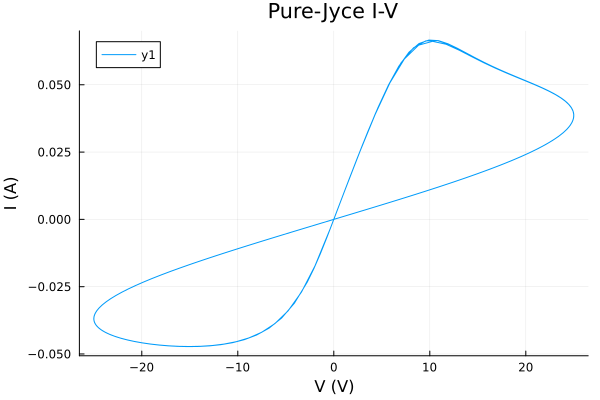

In [4]:
using Jyce, Plots
# Editable constants
amp = 25.0
freq = 250.0
dt = 1e-5
tstop = 1e-2

# Locate subckt next to the notebook
sub_candidates = [joinpath(@__DIR__, "biolek_mmrstor_model.sub"), "biolek_mmrstor_model.sub"]
sub = findfirst(isfile, sub_candidates) === nothing ? error("biolek_mmrstor_model.sub not found next to this notebook.") : abspath(sub_candidates[findfirst(isfile, sub_candidates)])
println("Using subcircuit: ", sub)

# Ensure native available before pure-Jyce run
if !Jyce.native_available()
  error("Jyce native backend not available. Run Cell 1 diagnostics and set JYCE_XYCESOLVER_JULIA_LIB or JYCE_XYCESOLVER_ROOT if needed.")
end

# Create simulator
sim = try Jyce.XyceSimulator(false) catch e; @error "Could not create XyceSimulator: " e; nothing; end
@assert sim !== nothing "Failed to construct Jyce.XyceSimulator; see Cell 1 diagnostics"

# Build an in-memory netlist string (includes the .sub file)
triple = """
* Pure-Jyce minimal test
.INCLUDE "$(sub)"
V1 IN 0 SIN(0 $(amp) $(freq))
XMEM IN 0 WPOS MEM_BIOLEK
.TRAN $(dt) $(tstop)
.PRINT TRAN V(IN) I(V1)
.END
"""

# Load netlist into sim and run
try
  Jyce.loadNetlistString(sim, triple)
catch e
  @error "loadNetlistString failed: " e
  rethrow(e)
end

# Force a stable PRN path (avoids /tmp cleanup issues)
forced_prn = joinpath(@__DIR__, "pure_jyce_minimal.prn")
result = Jyce.runSimulationOutput(sim, forced_prn)
@assert Jyce.simulation_success(result) Jyce.simulation_error_message(result)

prn_file = isfile(forced_prn) ? forced_prn : String(Jyce.simulation_prn_file_path(result))
@assert isfile(prn_file) "Data file not found: $(prn_file)"

println("prn path: ", prn_file)

# Plot from PRN
if isfile(prn_file)
  df = Jyce.read_simulation_data(prn_file)
  t = Float64.(df[:, Symbol("TIME")])
  v = Float64.(df[:, Symbol("V(IN)")])
  i = -Float64.(df[:, Symbol("I(V1)")])
  plot(v, i; xlabel="V (V)", ylabel="I (A)", title="Pure-Jyce I-V")
end